## Implementing Logistic Regression Algorithm

In [5]:
import import_ipynb
from base_model import BaseModel
import numpy as np

In [ ]:
class LogisticRegression(BaseModel): 
    ''' 
    Logistic Regression model implementation from scratch.

    Inherits from BaseModel and provides concrete implementation
    fot fit() and predict() methods.
    '''

    def __init__(self, learning_rate=0.001, iterations=1000, lambda_=0.0): 
        ''' 
        Initialize LogisticRegression model parameters.

        parameters
        ----------
        learning_rate : float
            Step size for gradient desecnt updates.
        iterations : int
            Number of iterations for gradient descent.
        lambda_ : float 
            My Regularization parameter (L2), default 0.0 (no regularization)

        Atributes
        ---------
        weights : ndarray of shape (n_features,)
            Model weights for each input feature. 
        bias: float
            Model bias term.
        '''
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.lambda_ = lambda_
        self.cost_history = []
        self.bias = None
        self.weights = None

    def sigmoid(self, z): 
        """
        Compute the sigmoid activation function.
    
        Parameters
        ----------
        z : float or array-like
            Input value(s)
    
        Returns
        -------
        float or array-like
            Sigmoid of input
        """
        
        g = 1 / (1 + np.exp(-z))

        return g

    def cost_function(self, X, y): 
        ''' 
        Compute the cost for all examples.

        Parameters
        ----------
        X : ndarray shape (m, n)
            where m, number of example and n, number of features
        y : ndarray shape (m,)
            Target Value

        Return
        ------
        Cost: 
        '''

        ## m, number of examples and n, number of features in X 
        m, n = X.shape
         
        cost = 0.
        for i in range(m): 
            fwb = np.dot(X[i], self.weights) + self.bias
            error = self.sigmoid(fwb)
            error = np.clip(error, 1e-15, 1 - 1e-15)
            cost += -((y[i] * np.log(error)) + ((1 - y[i]) * np.log(1 - error)))
        cost =  cost / m

        ## Regularization 
        regularized_cost = 0.
        for i in range(n): 
            regularized_cost += self.weights[i] ** 2
        regularized_cost = (self.lambda_ / (2 * m )) * regularized_cost

        # regularized_cost = (self.lambda_ / (2*m)) * sum(weights^2)

        ## Regularized cost + cost 
        t_cost = regularized_cost + cost

        return t_cost


    def gradient_function(self, X, y): 
        ''' 
        Computes the gradient for Logistic regression 
 
        Parameters
        ----------
          X : ndarray Shape (m,n)
              m, examples by n, features
          y : ndarray Shape (m,)
              Target value 
              
        Returns
        -------
          dj_dw : ndarray Shape (n,)
              The gradient of the cost w.r.t. the parameters w. 
          dj_db : (scalar)             
              The gradient of the cost w.r.t. the parameter b. 
        '''

        m, n = X.shape
        dj_dw = np.zeros(n)
        dj_db = 0. 

        for i in range(m):
            fwb = np.dot(X[i], self.weights) + self.bias
            error = self.sigmoid(fwb) - y[i]
            for j in range(n): 
                dj_dw[j] += error + X[i, j]
            dj_db +=  error
        
        dj_dw = dj_dw / m  
        dj_db = dj_db / m  

        # Regularized dj_dw
        for j in range(n): 
        dj_dw[j] += (lambda_ / m) * self.weights[j]
        
        return dj_dw, dj_db

    def fit(self, X, y):
        ''' 
        Train LogisticRegression using Batch Gradient Descent 
        (Uses the entire dataset at each iteration to compute the gradient and update parameters)

        Parameters
        ----------
        X: ndarray of shape (m, n)
            Training data where m is the number of examples and n is the number of features

        y : ndarray of shape (m,)
            Target values corresponding to each training example.

        Return
        ------
        None
        
        Notes
        -----
        This implementation follows the classical batch gradient descent procedure:
        1. Compute predictions for each example
        2. Compute prediction error
        3. Accumulate gradients for weights and bias
        4. Average gradients
        5. Apply regularization (if lambda_ > 0)
        6. Update parameters
        '''

        ## Number of examples m, and number of features n,
        m, n = X.shape

        ## Initializing the parameters 
        self.weights = np.zeros(n)
        self.bias = 0

        for iter_ in range(self.iterations):

            dj_dw, dj_db = self.gradient_function(X, y)

            self.weights = self.weights - self.learning_rate * dj_dw
            self.bias = self.bias - self.learning_rate * dj_db


            cost = self.cost_function(X, y)
            self.cost_history.append(cost)


    def predict(self, X, y):
        pass

        

        

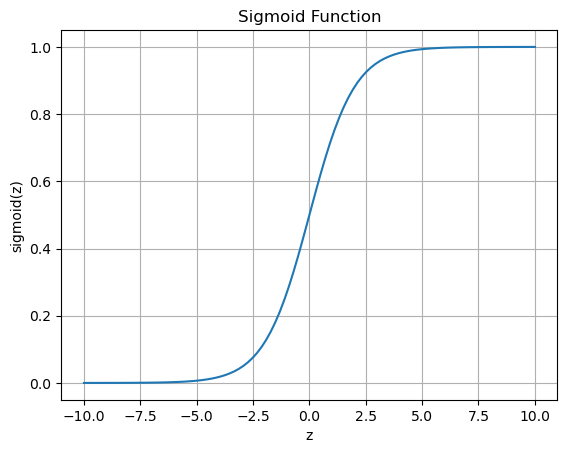

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate values
z = np.linspace(-10, 10, 100)
y = sigmoid(z)

# Plot
plt.plot(z, y)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.grid()
plt.show()